In [1]:
import os
import gc
import sys
import random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import soundfile as sf
from IPython.display import Audio, display

from collections import Counter
from pathlib import Path
from geopy.geocoders import Nominatim
import warnings
warnings.filterwarnings("ignore")

### CFG

In [2]:
class CFG:
    SEED     = 42
    base_dir = Path("/kaggle/input/competitions/birdclef-2026")

cf = CFG()

### Data

In [3]:
train_df          = pd.read_csv(os.path.join(cf.base_dir, "train.csv"))
taxonomy_df       = pd.read_csv(os.path.join(cf.base_dir, "taxonomy.csv"))
sample_sub        = pd.read_csv(os.path.join(cf.base_dir, "sample_submission.csv"))
soundscape_labels = pd.read_csv(os.path.join(cf.base_dir, "train_soundscapes_labels.csv"))

print(f"Train             : {train_df.shape}")
print(f"Taxonomy          : {taxonomy_df.shape}")
print(f"Submission        : {sample_sub.shape}")
print(f"Soundscape labels : {soundscape_labels.shape}")

Train             : (35549, 15)
Taxonomy          : (234, 5)
Submission        : (3, 235)
Soundscape labels : (1478, 4)


### Train

In [4]:
train_df.head(3)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat


In [5]:
print(f'Train primay Label Nunique: {train_df["primary_label"].nunique()}')
print(f'Train class name   Nunique: {train_df["class_name"].nunique()}')
print(f'Train Author       Nunique: {train_df["author"].nunique()}')
print(f'Train Url          Nunique: {train_df["url"].nunique()}')

Train primay Label Nunique: 206
Train class name   Nunique: 5
Train Author       Nunique: 4017
Train Url          Nunique: 35549


In [6]:
for i in train_df["primary_label"].unique().tolist():
    print(i, end=", ")

1161364, 116570, 1176823, 1595929, 209233, 22930, 22956, 22961, 22967, 22973, 22983, 22985, 23150, 23154, 23158, 23176, 23724, 24279, 24285, 24287, 24321, 244024, 25092, 25214, 326272, 41970, 43435, 47144, 476521, 516975, 555123, 555145, 555146, 64898, 65377, 65380, 66971, 67107, 67252, 70711, 738183, 74113, 74580, 760266, ashgre1, astcra1, bafcur1, baffal1, banana, barant1, batbel1, baymac, bbwduc, bcwfin2, bkcdon, bkhpar, blchaw1, blheag1, blttit1, bncfly, bobfly1, brcmar1, brnowl, bucmot4, bucpar, bufpar, bunibi1, burowl, camfli1, chacha1, chbmoc1, chobla1, chvcon1, cibspi1, coffal1, compau, compot1, crbthr1, crebec1, dwatin1, epaori4, eulfly1, fabwre1, fepowl, ficman1, flawar1, fotfly, fusfly1, gilhum1, giwrai1, glteme1, grasal3, greani1, greant1, greela, grekis, grepot1, gretho2, greyel, grfdov1, grhtan1, gycwor1, horscr1, houspa, hyamac1, larela1, lesela1, lesgrf1, limpki, linwoo1, litcuc2, litnig1, mabpar, magant1, magtan2, masgna1, nacnig1, ocecra1, oliwoo1, orbtro3, orwpar, os

In [7]:
train_df.head(1)

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat


In [8]:
train_df["secondary_labels"].unique()

array(['[]', "['compau']", "['saffin']", ...,
       "['whtdov', 'palhor3', 'rumfly1', 'plasla1', 'scadov1']",
       "['rutjac1', 'saffin']", "['fabwre1', 'whtdov', 'blttit1']"],
      dtype=object)

In [9]:
import ast
s = '["a", "b", "c"]'
l = ast.literal_eval(s)
print(l ,type(s),"==>" ,type(l))

['a', 'b', 'c'] <class 'str'> ==> <class 'list'>


In [10]:
def parse_list_field(val):
    """Parse a stringified list or return empty list."""
    if pd.isna(val) or val in ('[]', ''):
        return []
    try:
        parsed = ast.literal_eval(val)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []

train_df['secondary_labels_parsed'] = train_df['secondary_labels'].apply(parse_list_field)
train_df['n_secondary'] = train_df['secondary_labels_parsed'].apply(len)

print('Secondary label count distribution:')
print(train_df['n_secondary'].value_counts().sort_index().to_string())


Secondary label count distribution:
n_secondary
0     31177
1      2623
2      1049
3       379
4       169
5        87
6        35
7        11
8        12
9         1
10        2
11        1
12        2
15        1


In [11]:
F, S = train_df.loc[train_df["n_secondary"]==15, ["filename","secondary_labels_parsed"]].values.tolist()[0]
print(F)
print(S)

bkcdon/XC703631.ogg
['strcuc1', 'grasal3', 'watjac1', 'wfwduc1', 'pluibi1', 'rufhor2', 'whtdov', 'smbani', 'soulap1', 'souscr1', 'sobcac1', 'chobla1', 'grekis', 'astcra1', 'baymac']


In [12]:
def sample_plt(sample_file, offset=0.0, duration=10, japan=None):
    audio_path = os.path.join(cf.base_dir, "train_audio", sample_file)
    y, sr      = librosa.load(audio_path, duration=duration)
    species, common_name, class_name, rating, lon,  lat, secondary_labels_parsed = train_df.loc[train_df["filename"]==sample_file, ["primary_label", "common_name", "class_name", "rating", "longitude", "latitude", "secondary_labels_parsed"]].values.tolist()[0]
    country = get_country(lon, lat)
    
    print(f"Sample file: {sample_file}")
    print(f"Class Name : {class_name}")
    if japan is not None:
        print(f"{japan[class_name]}")
    print(f"Species    : {species}")
    print(f"Secondary  : {secondary_labels_parsed}")
    print(f"Common Name: {common_name}")
    print(f"Sample rate: {sr:,} Hz")
    print(f"Duration   : {len(y)/sr:.1f} Seconds")
    print(f"User Rating: {rating}")
    print(f"Country    : {country}")

    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))
    axes_list = axes.flatten()
    total_duration = len(y)/sr
    # Waveform
    librosa.display.waveshow(y=y, sr=sr, ax=axes_list[0], x_axis="time", color="steelblue")
    axes_list[0].set_xlim(0, total_duration)
    axes_list[0].set_title("Waveform - Guyalana cuta", size=18)
    axes_list[0].set_xlabel("Time (seconds)", size=12)
    axes_list[0].set_ylabel("Amplitude")

    # Mel Spectorogram
    mel_spec    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes_list[1])
    axes_list[1].set_xlim(0, total_duration)
    #plt.colorbar(axes_list[1].collections[0], ax=axes_list[1], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()

    # Audio
    display(Audio(y, rate=sr))

def rating_sounds(rating, class_name):
    tmp = train_df.loc[(train_df["rating"] == rating)&(train_df["class_name"]==class_name), "filename"]
    print(f"file length: {len(tmp)}")
    if not tmp.values.any():
        print("Enpty!!!")

    s_file = random.choice(tmp.tolist())
    sample_plt(s_file)

geolocator = Nominatim(user_agent="my_kaggel_notebook")
def get_country(lon, lat):
    try:
        location = geolocator.reverse((lat, lon), language='en')
        if location:
            return location.raw["address"].get("country", "")
        return None
    except:
        return None

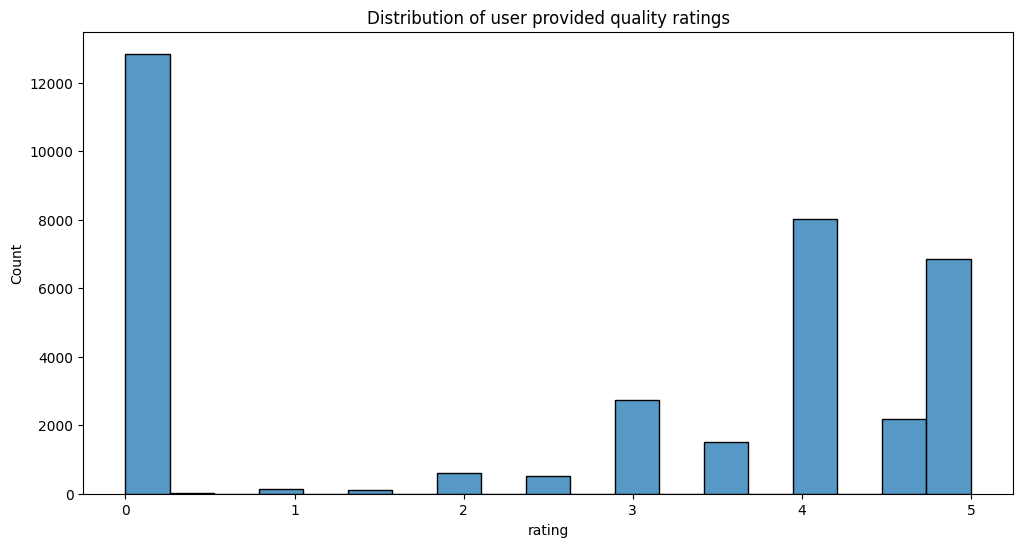

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(data=train_df, x="rating")
plt.title("Distribution of user provided quality ratings", size=12)
plt.show()

file length: 12190
Sample file: strowl1/iNat761503.ogg
Class Name : Aves
Species    : strowl1
Secondary  : []
Common Name: Striped Owl
Sample rate: 22,050 Hz
Duration   : 10.0 Seconds
User Rating: 0.0
Country    : Brazil


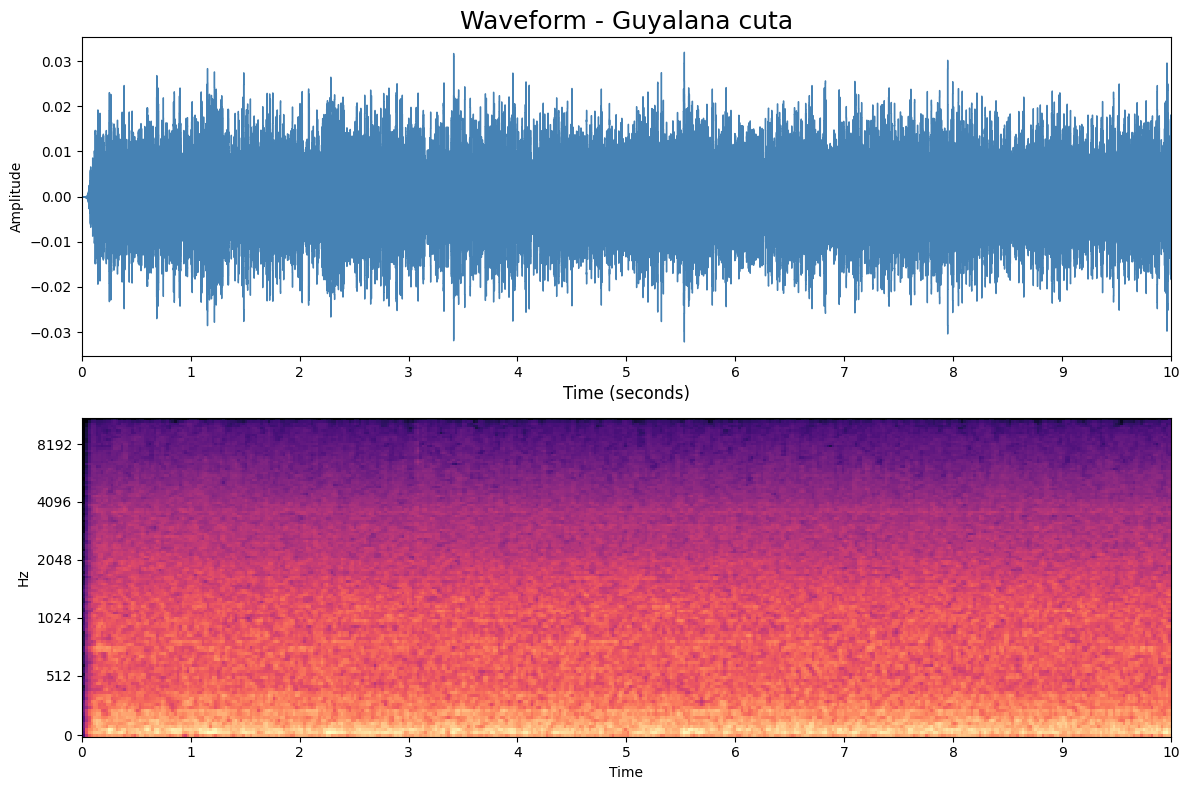

file length: 6812
Sample file: soulap1/XC131751.ogg
Class Name : Aves
Species    : soulap1
Secondary  : []
Common Name: Southern Lapwing
Sample rate: 22,050 Hz
Duration   : 6.9 Seconds
User Rating: 5.0
Country    : Colombia


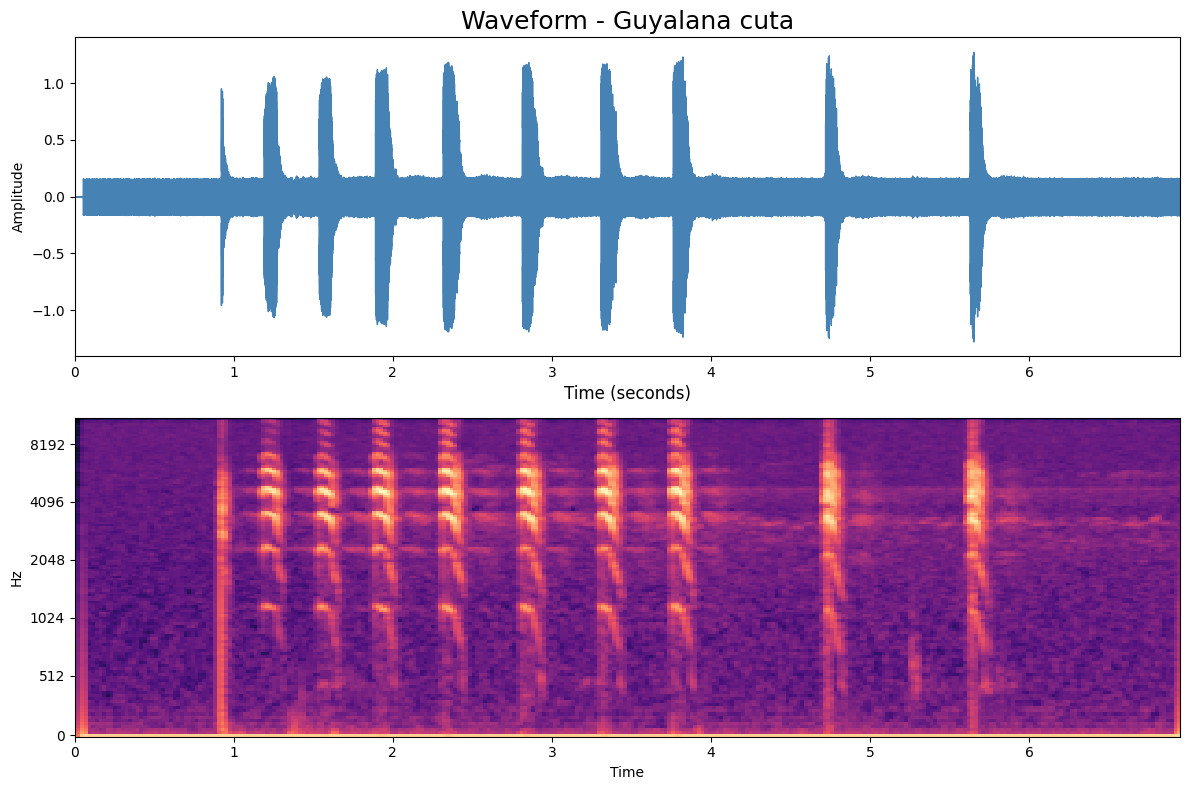

In [14]:
rating_sounds(0, "Aves")
rating_sounds(5, "Aves")

In [15]:
jp_dict = {
    "Amphibia": "両生類",
    "Aves"    : "鳥類",
    "Insecta" : "昆虫",
    "Mammalia": "哺乳類",
    "Reptilia": "爬虫類",
}

Sample file: strher2/XC961357.ogg
Class Name : Aves
鳥類
Species    : strher2
Secondary  : ['soulap1', 'grekis']
Common Name: Striated Heron
Sample rate: 22,050 Hz
Duration   : 10.0 Seconds
User Rating: 4.5
Country    : Brazil


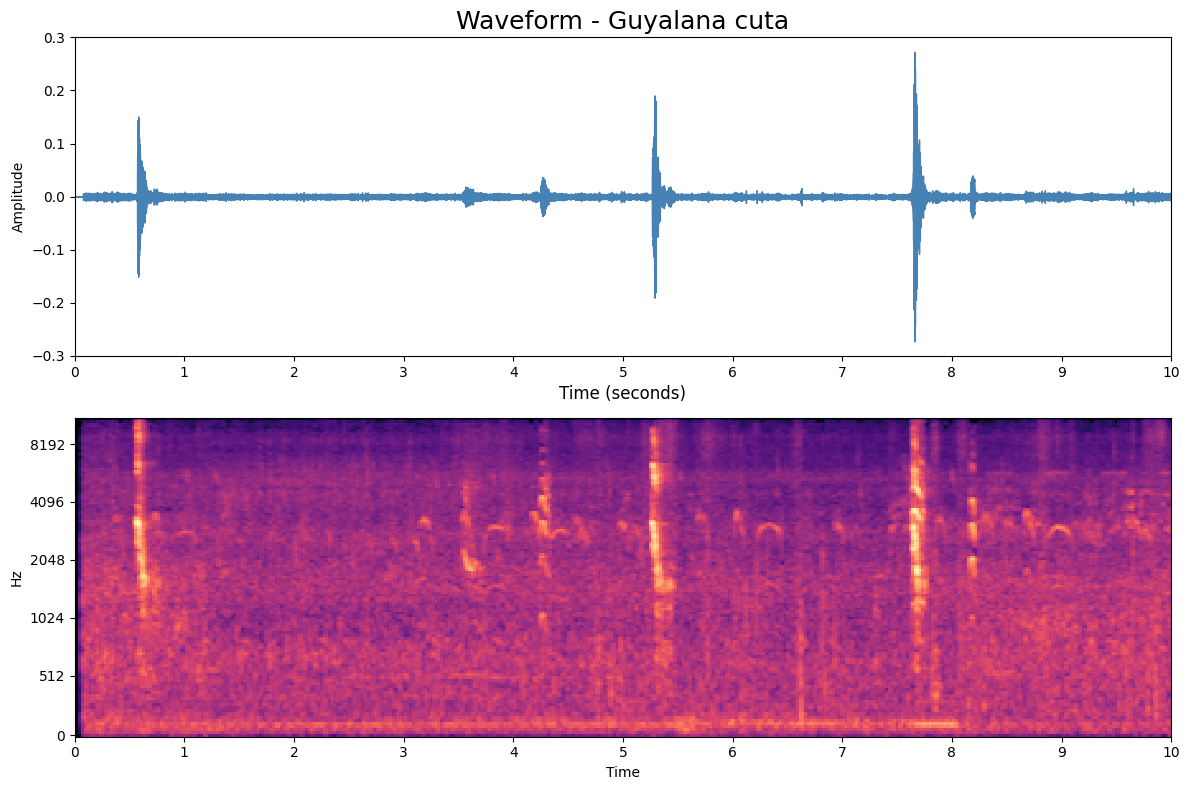

In [16]:
sample_f = random.choice(train_df["filename"].unique())
sample_plt(sample_f, japan=jp_dict)

Sample file: bkcdon/XC703631.ogg
Class Name : Aves
鳥類
Species    : bkcdon
Secondary  : ['strcuc1', 'grasal3', 'watjac1', 'wfwduc1', 'pluibi1', 'rufhor2', 'whtdov', 'smbani', 'soulap1', 'souscr1', 'sobcac1', 'chobla1', 'grekis', 'astcra1', 'baymac']
Common Name: Black-capped Donacobius
Sample rate: 22,050 Hz
Duration   : 10.0 Seconds
User Rating: 4.5
Country    : Bolivia


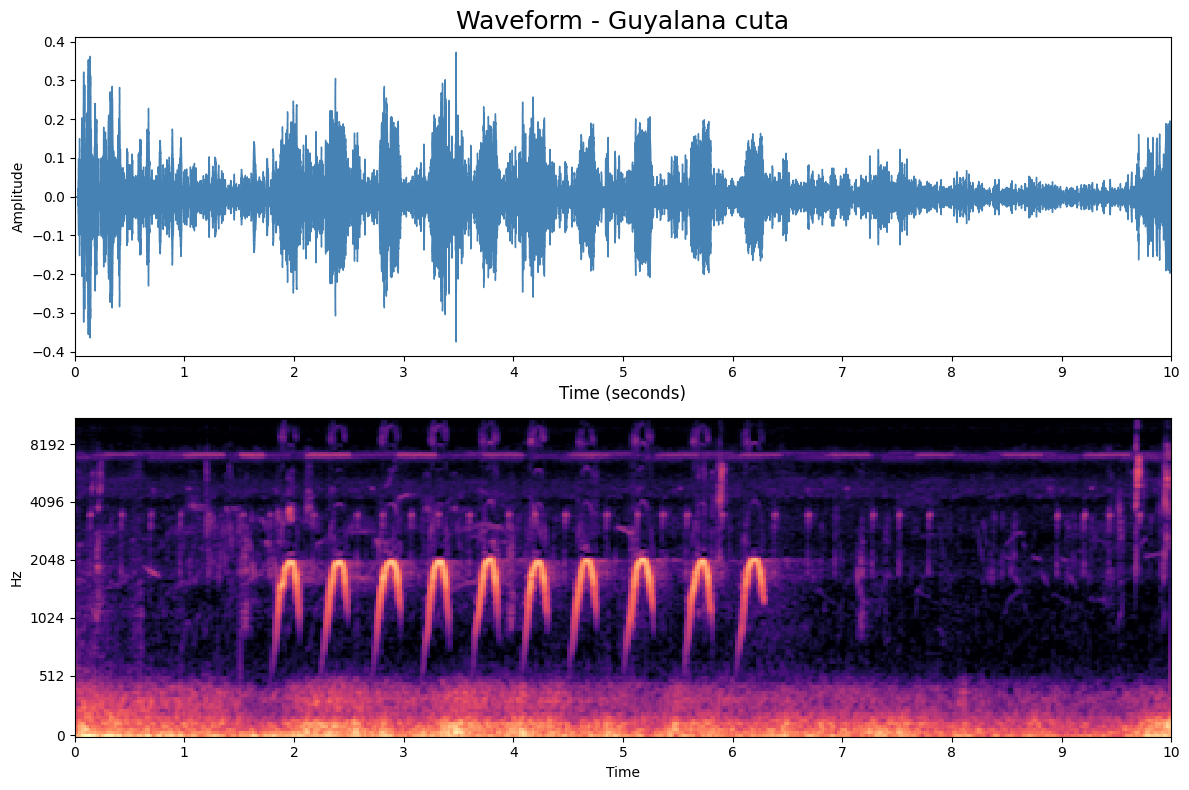

In [17]:
f = 'bkcdon/XC703631.ogg'
sample_plt(f, japan=jp_dict)

### Taxonomy

In [18]:
taxonomy_df.head(3)

,primary_label,inat_taxon_id,scientific_name,common_name,class_name
0,1161364,1161364,Guyalna cuta,Guyalna cuta,Insecta
1,116570,116570,Caiman yacare,Southern Spectacled Caiman,Reptilia
2,1176823,1176823,Leptodactylus luctator,Wrestler Frog,Amphibia


In [19]:
taxonomy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   primary_label    234 non-null    object
 1   inat_taxon_id    234 non-null    int64 
 2   scientific_name  234 non-null    object
 3   common_name      234 non-null    object
 4   class_name       234 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.3+ KB


In [20]:
print(f'Taxonomy primary label Nunique: {taxonomy_df["primary_label"].nunique()}')
print(f'Taxonomy inat taxon id Nunique: {taxonomy_df["inat_taxon_id"].nunique()}')
print(f'Taxonomy scientific n  Nunique: {taxonomy_df["scientific_name"].nunique()}')
print(f'Taxonomy common name   Nunique: {taxonomy_df["common_name"].nunique()}')
print(f'Taxonomy class name    Nunique: {taxonomy_df["class_name"].nunique()}')

Taxonomy primary label Nunique: 234
Taxonomy inat taxon id Nunique: 210
Taxonomy scientific n  Nunique: 234
Taxonomy common name   Nunique: 234
Taxonomy class name    Nunique: 5


In [21]:
taxonomy_df["class_name"].value_counts().to_frame().reset_index()

,class_name,count
0,Aves,162
1,Amphibia,35
2,Insecta,28
3,Mammalia,8
4,Reptilia,1


In [22]:
for c in taxonomy_df["class_name"].unique():
    subset = taxonomy_df[taxonomy_df["class_name"]== c][["primary_label", "common_name"]]
    print(f"{c:<15} ({subset['common_name'].nunique()} Species)")
    print()

Insecta         (28 Species)

Reptilia        (1 Species)

Amphibia        (35 Species)

Mammalia        (8 Species)

Aves            (162 Species)



In [23]:
for C_N in taxonomy_df["class_name"].unique():
    subset = taxonomy_df.loc[taxonomy_df["class_name"] == C_N, ["primary_label", "common_name"]].reset_index(drop=True)
    print(f"{C_N} ({len(subset)} Species)")
    display(subset.head(5))

Insecta (28 Species)


,primary_label,common_name
0,1161364,Guyalna cuta
1,244024,Giant Cicada
2,47158son01,Insect sonotype01
3,47158son02,Insect sonotype02
4,47158son03,Insect sonotype03


Reptilia (1 Species)


,primary_label,common_name
0,116570,Southern Spectacled Caiman


Amphibia (35 Species)


,primary_label,common_name
0,1176823,Wrestler Frog
1,1491113,Guaraní leaf-litter frog
2,1595929,Uruguay Harlequin Frog
3,22930,Basin White-lipped Frog
4,22956,Mustached Frog


Mammalia (8 Species)


,primary_label,common_name
0,209233,Feral Horse
1,41970,Jaguar
2,43435,Black Howling Monkey
3,47144,Domestic Dog
4,516975,Hooded Capuchin


Aves (162 Species)


,primary_label,common_name
0,ashgre1,Ashy-headed Greenlet
1,astcra1,Ash-throated Crake
2,bafcur1,Bare-faced Curassow
3,baffal1,Barred Forest-Falcon
4,banana,Bananaquit


In [24]:
for c in sorted(train_df["class_name"].unique()):
    subset = train_df[train_df["class_name"]== c][["primary_label", "common_name"]]
    print(f"{c:<15} ({subset['common_name'].nunique()} Species)")
    print()


Amphibia        (32 Species)

Aves            (162 Species)

Insecta         (3 Species)

Mammalia        (8 Species)

Reptilia        (1 Species)



In [25]:
colors = ["green", "steelblue","orange", "red", "purple"]
class_n= sorted(taxonomy_df["class_name"].unique())
color_dict = {k:v for k, v in zip(class_n, colors)}
color_dict

{'Amphibia': 'green',
 'Aves': 'steelblue',
 'Insecta': 'orange',
 'Mammalia': 'red',
 'Reptilia': 'purple'}

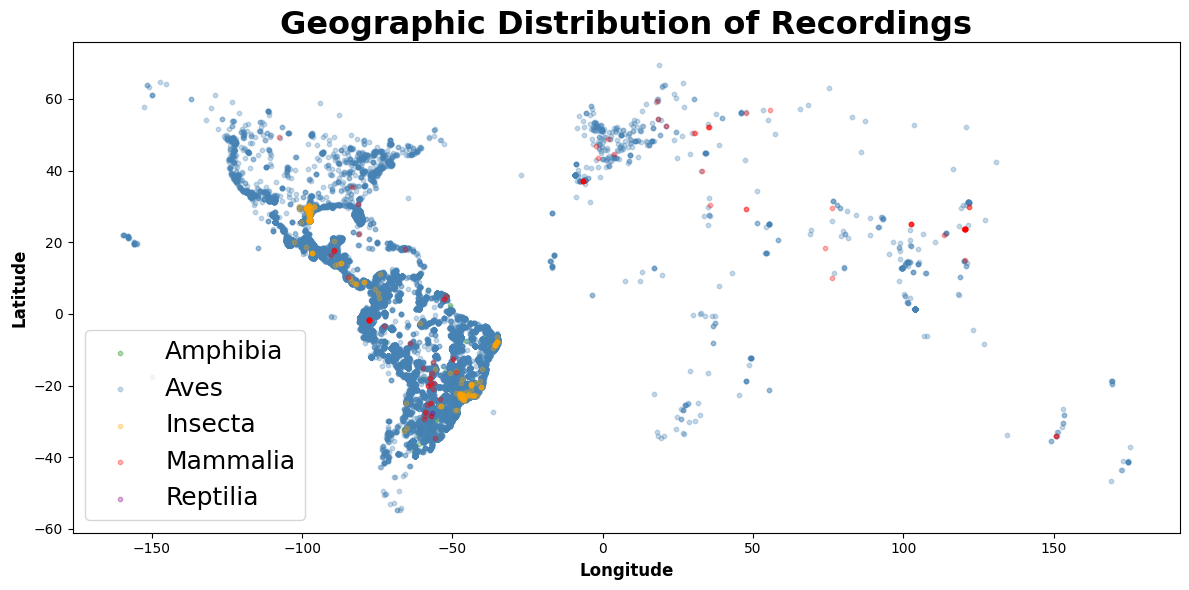

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))
for class_name, group in train_df.groupby("class_name"):
    ax.scatter(x=group["longitude"], 
               y=group["latitude"], 
               label=class_name, 
               color=color_dict[class_name],
               alpha=0.3, 
               s=10
              )
ax.set_title('Geographic Distribution of Recordings', size=23, fontweight="bold")
ax.set_xlabel('Longitude', size=12, fontweight="bold")
ax.set_ylabel('Latitude',  size=12, fontweight="bold")
ax.legend(fontsize=18)
plt.tight_layout()
plt.show()

{'iNat': 'green', 'XC': 'steelblue'}


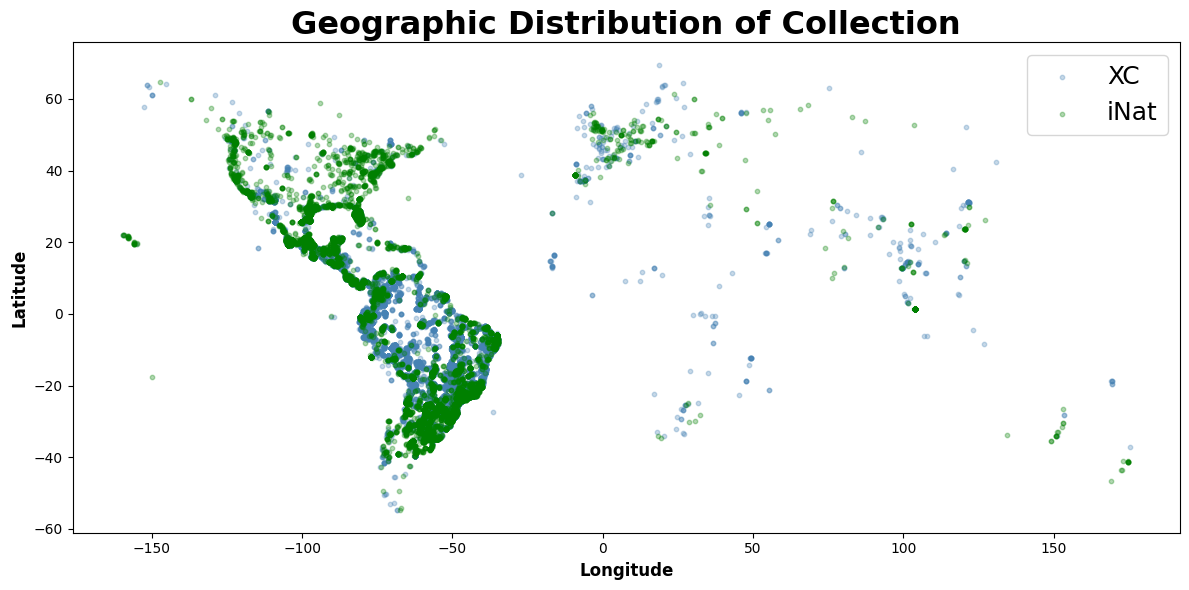

In [27]:
c_colors = ["green", "steelblue"]
collection_name = train_df["collection"].unique()
c_dict = {k:v for k, v in zip(collection_name, c_colors)}
print(c_dict)
fig, ax = plt.subplots(figsize=(12, 6))
for c, g in train_df.groupby("collection"):
    ax.scatter(x=g["longitude"], 
               y=g["latitude"], 
               label=c, 
               color=c_dict[c],
               alpha=0.3, 
               s=10
              )
ax.set_title('Geographic Distribution of Collection', size=23, fontweight="bold")
ax.set_xlabel('Longitude', size=12, fontweight="bold")
ax.set_ylabel('Latitude',  size=12, fontweight="bold")
ax.legend(fontsize=18)
plt.tight_layout()
plt.show()

Class num  : 451
Sample file: 555145/iNat1242826.ogg
Class Name : Amphibia
両生類
Species    : 555145
Secondary  : []
Common Name: Polka-dot Tree Frog
Sample rate: 22,050 Hz
Duration   : 9.9 Seconds
User Rating: 0.0
Country    : Brazil


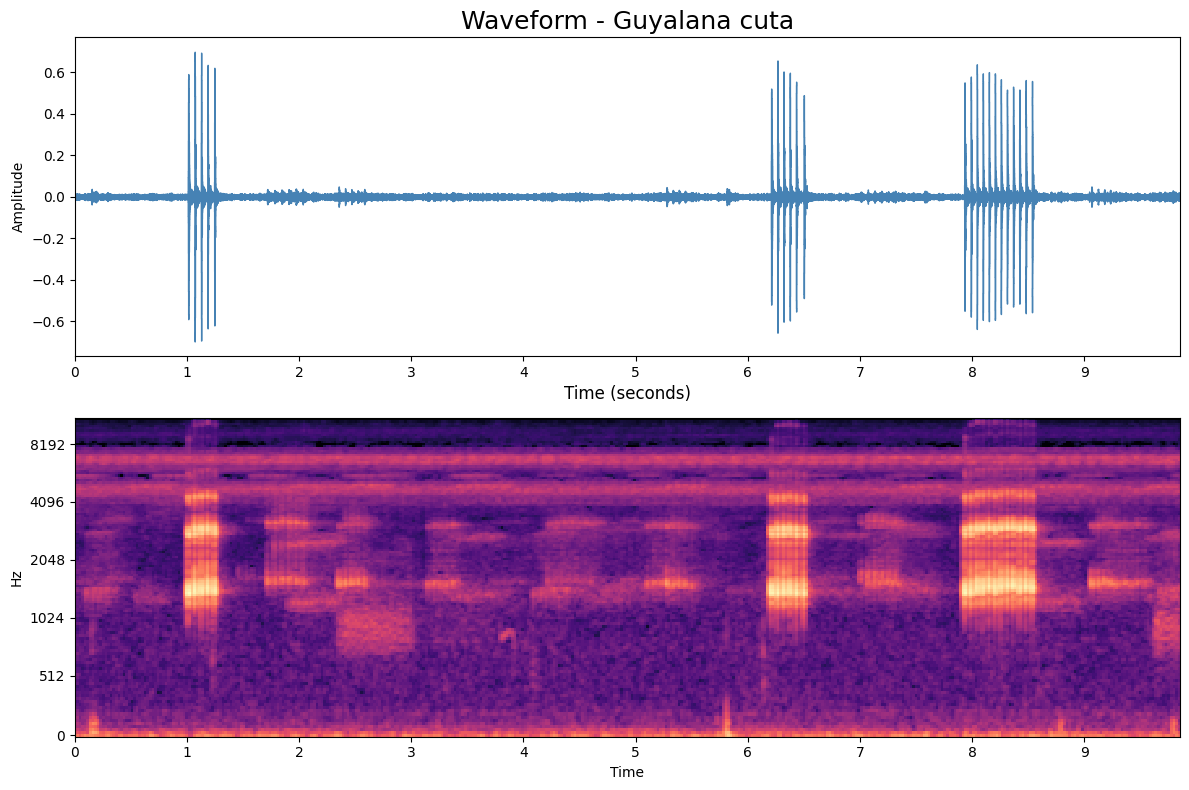

Class num  : 34799
Sample file: grepot1/XC637226.ogg
Class Name : Aves
鳥類
Species    : grepot1
Secondary  : []
Common Name: Great Potoo
Sample rate: 22,050 Hz
Duration   : 9.2 Seconds
User Rating: 4.0
Country    : Panama


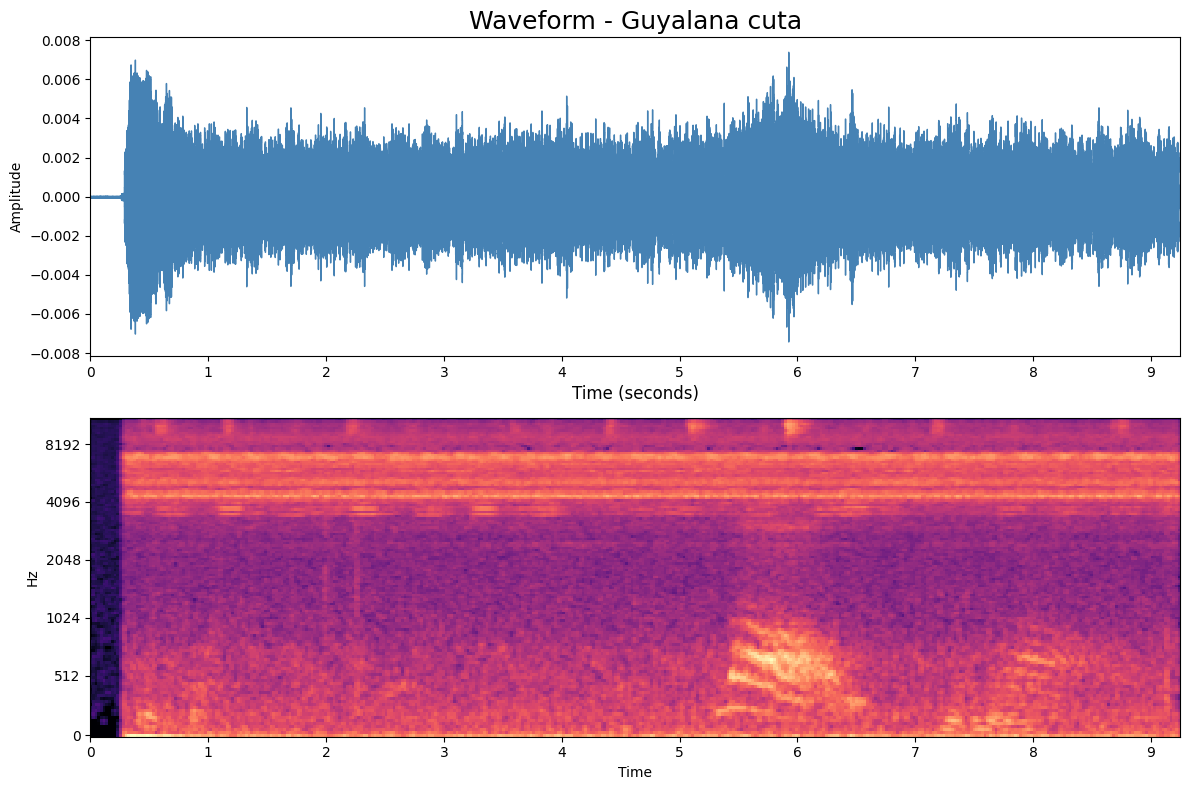

Class num  : 199
Sample file: 244024/iNat556810.ogg
Class Name : Insecta
昆虫
Species    : 244024
Secondary  : []
Common Name: Giant Cicada
Sample rate: 22,050 Hz
Duration   : 10.0 Seconds
User Rating: 0.0
Country    : Brazil


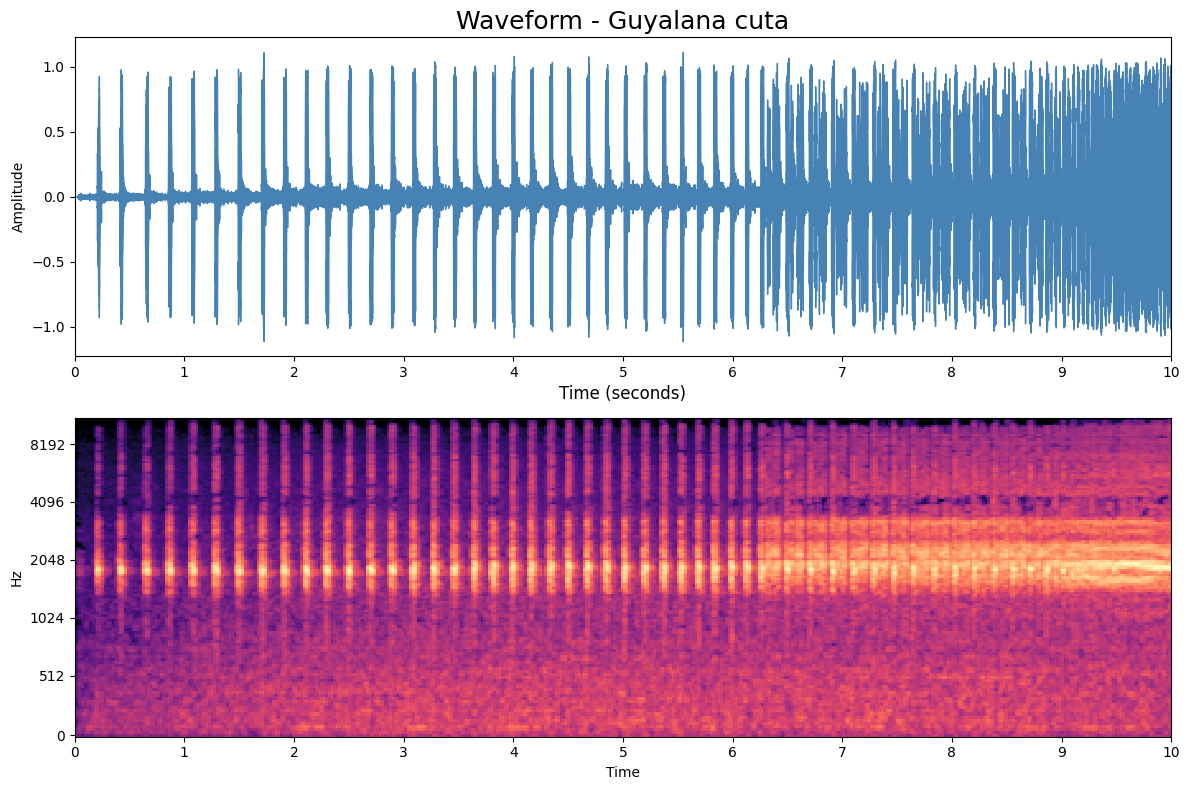

Class num  : 99
Sample file: 43435/iNat1651689.ogg
Class Name : Mammalia
哺乳類
Species    : 43435
Secondary  : []
Common Name: Black Howling Monkey
Sample rate: 22,050 Hz
Duration   : 10.0 Seconds
User Rating: 0.0
Country    : Brazil


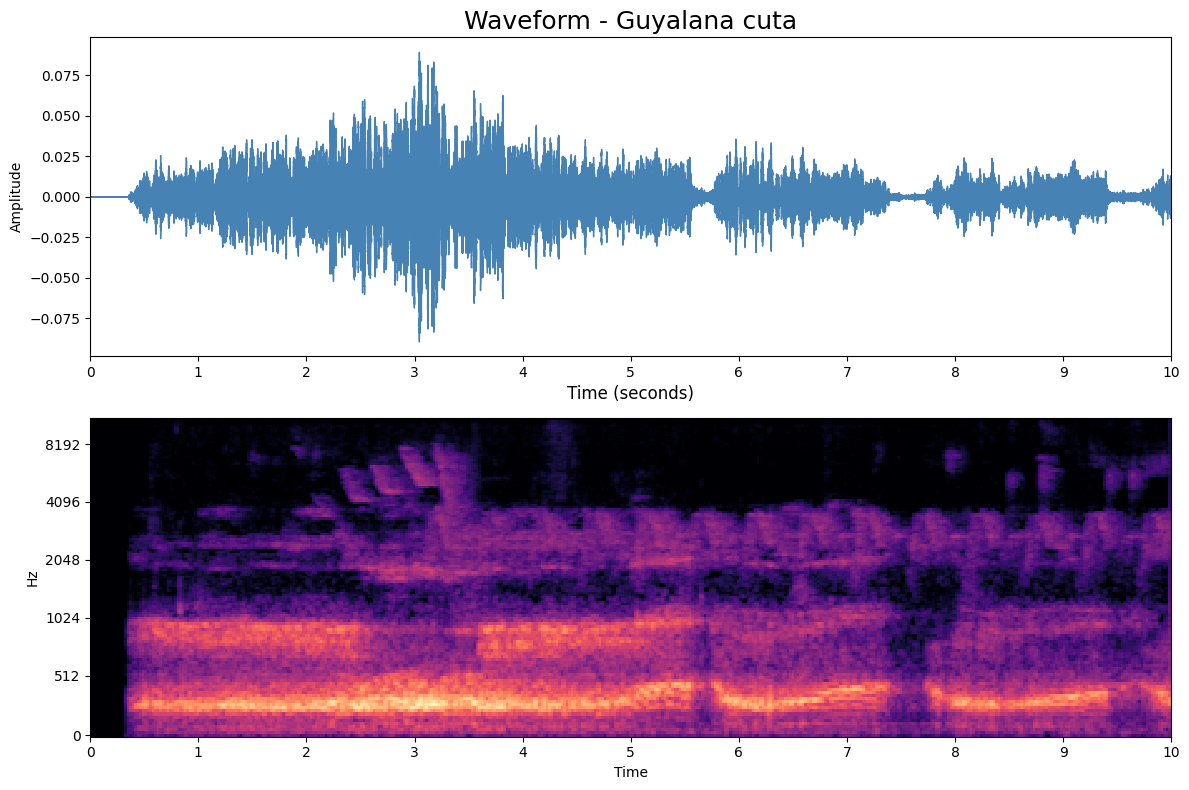

Class num  : 1
Sample file: 116570/iNat1460166.ogg
Class Name : Reptilia
爬虫類
Species    : 116570
Secondary  : []
Common Name: Southern Spectacled Caiman
Sample rate: 22,050 Hz
Duration   : 7.9 Seconds
User Rating: 0.0
Country    : Argentina


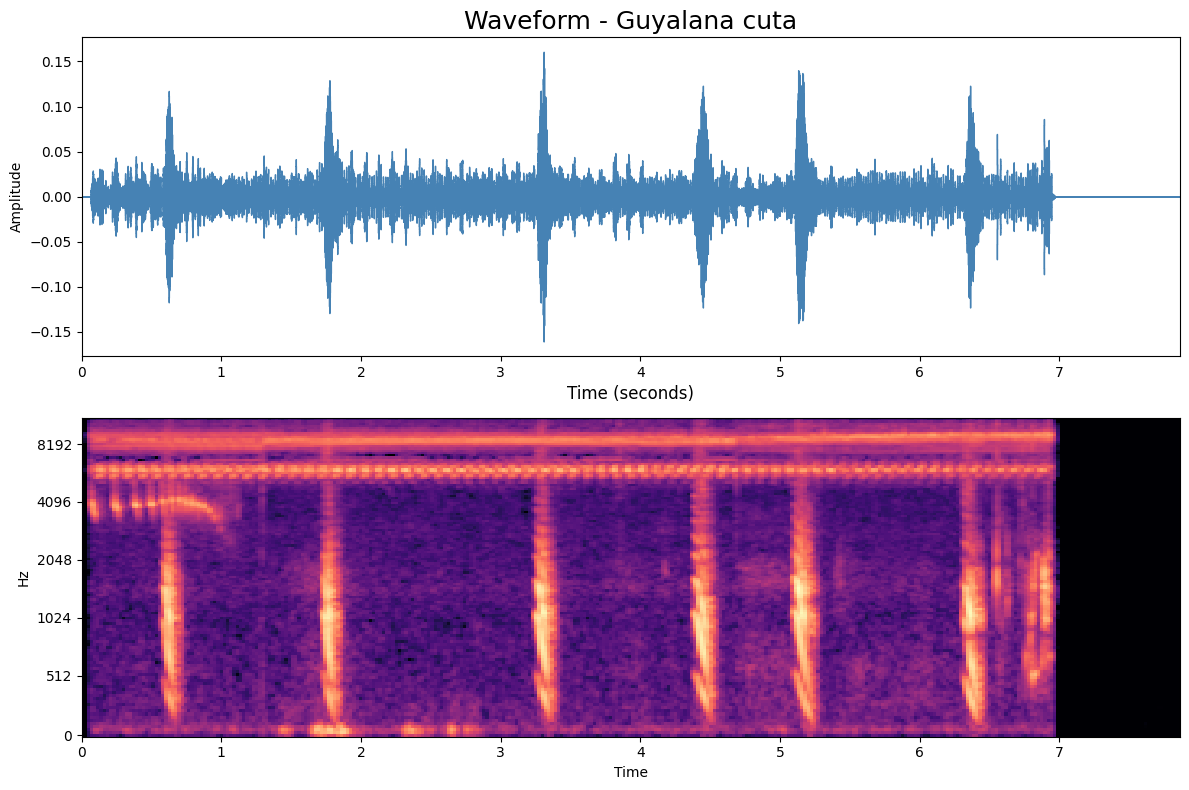

In [28]:
for class_name in color_dict.keys():
    class_list  = train_df.loc[train_df["class_name"] == class_name, "filename"].unique().tolist()
    print(f"Class num  : {len(class_list)}")
    sample_path = random.choice(class_list)
    sample_plt(sample_path, japan=jp_dict)

### Soundscape Labels

In [29]:
soundscape_labels.shape

(1478, 4)

In [30]:
soundscape_labels.head(3)

,filename,start,end,primary_label
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,22961;23158;24321;517063;65380


In [31]:
print(f'Soundscape filename Nunique {soundscape_labels["filename"].nunique()}')

Soundscape filename Nunique 66


In [32]:
soundscape_labels.groupby("filename")["filename"].count().sort_values().head(10)

filename
BC2026_Train_0006_S09_20250828_000000.ogg     4
BC2026_Train_0009_S09_20250828_000000.ogg     4
BC2026_Train_0010_S09_20250828_000000.ogg     4
BC2026_Train_0015_S18_20211016_011500.ogg     6
BC2026_Train_0008_S09_20250831_000000.ogg    10
BC2026_Train_0007_S09_20250829_000000.ogg    16
BC2026_Train_0026_S22_20211128_004500.ogg    18
BC2026_Train_0004_S08_20250607_070007.ogg    24
BC2026_Train_0005_S08_20250607_070007.ogg    24
BC2026_Train_0002_S08_20250607_030007.ogg    24
Name: filename, dtype: int64

In [33]:
len(soundscape_labels) - (66-7) * 24 

62

In [34]:
print(f'soundscape Primary label Nunique: {soundscape_labels["primary_label"].nunique()}')

soundscape Primary label Nunique: 251


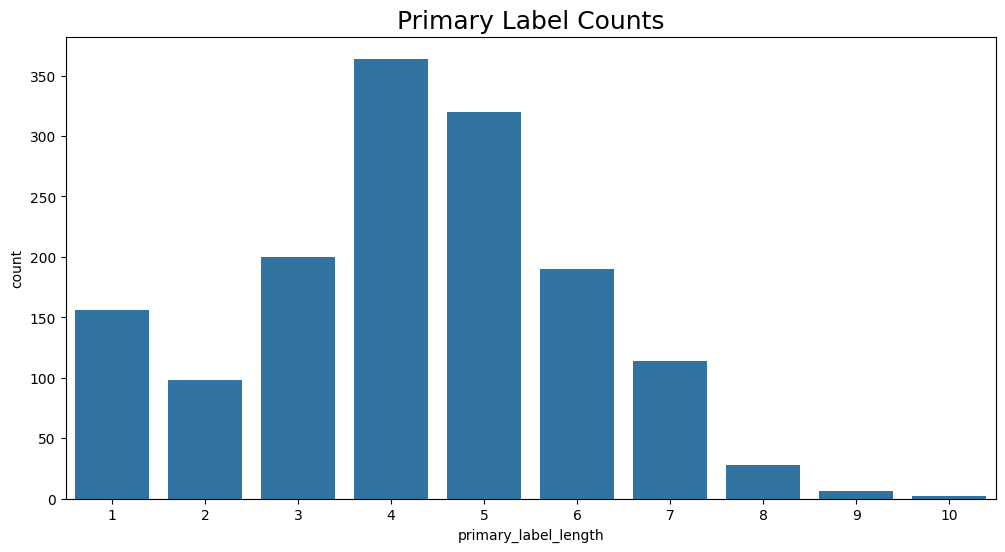

In [35]:
soundscape_labels["primary_label_length"] = soundscape_labels["primary_label"].map(lambda x: len(x.split(";")))

plt.figure(figsize=(12, 6))
sns.countplot(data=soundscape_labels, x="primary_label_length")
plt.title("Primary Label Counts", size=18)
plt.show()

In [36]:
train_df["primary_label"].value_counts().head(10)

primary_label
rubthr1    499
banana     498
fepowl     497
soulap1    497
houspa     496
coffal1    495
osprey     495
socfly1    494
compau     493
yeofly1    493
Name: count, dtype: int64

In [37]:
soundscape_labels["primary_label"].str.split(";").explode().value_counts().head(10)

primary_label
65380         666
517063        626
22973         426
555146        420
23158         350
24279         346
24321         344
22967         310
66971         298
47158son25    168
Name: count, dtype: int64

In [38]:
train_species_unique_list = train_df["primary_label"].unique().tolist()
len(train_species_unique_list)

206

In [39]:
soundscape_labels["primary_label"].dtype

dtype('O')

In [40]:
def parse_labels(val):
    """Split semicolon-separated label IDs."""
    if pd.isna(val) or val == '':
        return []
    return [v.strip() for v in str(val).split(';') if v.strip()]

soundscape_labels["labels_list"] = soundscape_labels["primary_label"].apply(parse_labels)

In [41]:
soundscape_labels["n_labels"] = soundscape_labels["labels_list"].apply(len)
soundscape_labels["n_labels"].value_counts().sort_index()

n_labels
1     156
2      98
3     200
4     364
5     320
6     190
7     114
8      28
9       6
10      2
Name: count, dtype: int64

In [42]:
soundscape_labels.head(2)

,filename,start,end,primary_label,primary_label_length,labels_list,n_labels
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,22961;23158;24321;517063;65380,5,"[22961, 23158, 24321, 517063, 65380]",5
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,22961;23158;24321;517063;65380,5,"[22961, 23158, 24321, 517063, 65380]",5


In [43]:
soundscape_species_unique_list = soundscape_labels["primary_label"].str.split(";").explode().unique().tolist()
len(soundscape_species_unique_list)

75

In [44]:
soundscape_only_species_list = (set(soundscape_species_unique_list)).difference(set(train_species_unique_list))
print(f"Soundscape labels Only Species Counts {len(soundscape_only_species_list)}")

Soundscape labels Only Species Counts 28


In [45]:
train_only_species_list = set(train_species_unique_list).difference(set(soundscape_species_unique_list))
print(f"Train Only Species Counts {len(train_only_species_list)}")

Train Only Species Counts 159


In [46]:
same_species_list = sorted(list(set(train_species_unique_list).intersection((soundscape_species_unique_list))))
print(same_species_list, " ,")
print("Same Species Counts",len(same_species_list))

['116570', '22961', '22967', '22973', '23158', '24279', '24321', '25092', '326272', '43435', '47144', '516975', '555146', '65377', '65380', '66971', '67107', '67252', '74113', 'bafcur1', 'bufpar', 'bunibi1', 'chacha1', 'chvcon1', 'compau', 'compot1', 'fusfly1', 'grekis', 'hyamac1', 'limpki', 'litnig1', 'magant1', 'nacnig1', 'orwpar', 'plcjay1', 'purjay1', 'redjun', 'rufhor2', 'ruther1', 'rutjac1', 'sibtan2', 'strher2', 'thlwre1', 'trsowl', 'undtin1', 'wfwduc1', 'whtdov']  ,
Same Species Counts 47


### Merged

In [47]:
train_df.shape, taxonomy_df.shape

((35549, 17), (234, 5))

In [48]:
train_df["primary_label"].nunique(), taxonomy_df["primary_label"].nunique()

(206, 234)

In [49]:
print(set(taxonomy_df["primary_label"]).difference(set(train_df["primary_label"])))
print()
print("Difference Primary label",len(set(taxonomy_df["primary_label"]).difference(set(train_df["primary_label"]))))

{'47158son15', '47158son20', '47158son12', '47158son22', '47158son23', '47158son11', '47158son03', '47158son07', '47158son02', '47158son16', '47158son25', '47158son18', '47158son17', '47158son24', '47158son13', '47158son10', '47158son04', '47158son09', '47158son06', '25073', '47158son01', '47158son14', '47158son19', '47158son21', '47158son08', '1491113', '47158son05', '517063'}

Difference Primary label 28


In [50]:
train_df["class_name"].nunique(), taxonomy_df["class_name"].nunique()

(5, 5)

In [51]:
train_merged = train_df.merge(taxonomy_df[["primary_label", "class_name"]], 
                              on="primary_label", 
                              how="left",
                              suffixes=("_train", "")
                             ) 
display(train_merged.head())
print(f"merged Shape: {train_merged.shape}")

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name_train,inat_taxon_id,author,license,rating,url,filename,collection,secondary_labels_parsed,n_secondary,class_name
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat,[],0,Insecta
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat,[],0,Insecta
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat,[],0,Insecta
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat,[],0,Insecta
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat,[],0,Insecta


merged Shape: (35549, 18)


In [52]:
(train_merged["class_name_train"] == train_merged["class_name"]).all()

np.True_

In [53]:
train_merged["primary_label"].nunique()

206

### Submission

In [54]:
sample_sub.head()

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Test_0001_S05_20250227_010002_5,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
1,BC2026_Test_0001_S05_20250227_010002_10,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274
2,BC2026_Test_0001_S05_20250227_010002_15,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,...,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274,0.004274


In [55]:
submission_targets_list = [col for col in sample_sub.columns if not col == "row_id"]
print(f"Submission Targets Length: {len(submission_targets_list)}")

Submission Targets Length: 234


In [56]:
taxonomy_df_primary_label_list = taxonomy_df["primary_label"].tolist()
print(f"Taxonomy Primary Label Length: {len(taxonomy_df_primary_label_list)}")

Taxonomy Primary Label Length: 234


In [57]:
set(taxonomy_df_primary_label_list).difference(set(submission_targets_list))

set()

In [58]:
taxonomy_df_primary_label_list == submission_targets_list

True

### Test

In [59]:
np.random.seed(cf.SEED)

In [60]:
test_soundscape_path = os.path.join(cf.base_dir, "test_soundscapes")
test_soundscape_path

'/kaggle/input/competitions/birdclef-2026/test_soundscapes'

In [61]:
test_soundscapes = [os.path.join(test_soundscape_path, file) for file in  sorted(os.listdir(test_soundscape_path)) if file.endswith(".ogg")]
test_soundscapes

[]

In [62]:
class_labels = taxonomy_df_primary_label_list.copy()

In [63]:
pred_df = pd.DataFrame(columns=["row_id"] + class_labels)
pred_df

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1


In [64]:
for soundscape in test_soundscapes:
    sig, rate = librosa.load(path=soundscape, sr=None)

    chunks = []
    for i in range(0, len(sig), rate*5):
        chunk = sig[i: i+rate*5]
        chunks.append(chunk)
    for e, chunk in enumerate(chunks):
        row_id = os.path.basename(soundscape).split(".")[0] + f"_{e * 5 + 5}"

        socres = np.random.rand(len(class_labels))
        new_row = pd.DataFrame([[row_id] + list(scores)],
                               columns=["row_id"] + class_labels
                              )
        pred_df = pd.concat([pred_df, new_row], axis=0, ignore_index=True)

pred_df.to_csv("submission.csv", index=False)
pred_df.head()
    

,row_id,1161364,116570,1176823,1491113,1595929,209233,22930,22956,22961,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
